# FibrosisViT — Phase 1: Baseline
### OSIC Pulmonary Fibrosis Progression Prediction
**Goal:** Establish a tabular-only baseline score using the Laplace Log-Likelihood metric.  
Every future phase (2D ViT → 3D Swin → FibrosisViT) must beat this number.

---
**Pipeline overview:**
1. Environment setup
2. Exploratory Data Analysis (EDA)
3. Feature engineering
4. Tabular baseline model (QuantileNet MLP)
5. Results & visualisation
6. CT scan preprocessing (cache for Phase 2+)


## 1. Environment Setup

In [2]:
!pip install pydicom SimpleITK tqdm -q

import os, sys, shutil, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import KFold, GroupKFold

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ── Colour palette for all plots ────────────────────────────────────────────
BLUE   = "#378ADD"
TEAL   = "#1D9E75"
CORAL  = "#D85A30"
PURPLE = "#7F77DD"
AMBER  = "#EF9F27"
GRAY   = "#888780"
PALETTE = [BLUE, TEAL, CORAL, PURPLE, AMBER, GRAY]

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.family":      "DejaVu Sans",
    "font.size":        11,
})

os.makedirs("outputs", exist_ok=True)
print("Libraries loaded")
print(f"PyTorch {torch.__version__}  |  GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")


Libraries loaded
PyTorch 2.10.0+cu128  |  GPU: Tesla T4


## 2. Load Data

In [3]:
BASE = "/kaggle/input/competitions/osic-pulmonary-fibrosis-progression"
os.makedirs("data/raw", exist_ok=True)

for f in ["train.csv", "test.csv", "sample_submission.csv"]:
    dst = f"data/raw/{f}"
    if not os.path.exists(dst):
        shutil.copy(f"{BASE}/{f}", dst)

train = pd.read_csv("data/raw/train.csv")
test  = pd.read_csv("data/raw/test.csv")
sub   = pd.read_csv("data/raw/sample_submission.csv")

In [4]:
print(f"Train : {train.shape[0]:,} rows  |  {train['Patient'].nunique()} patients")
print(f"Test  : {test.shape[0]:,} rows   |  {test['Patient'].nunique()} patients")


Train : 1,549 rows  |  176 patients
Test  : 5 rows   |  5 patients


In [5]:
print("Columns:", train.columns.tolist())

Columns: ['Patient', 'Weeks', 'FVC', 'Percent', 'Age', 'Sex', 'SmokingStatus']


In [6]:
train.head()

,Patient,Weeks,FVC,Percent,Age,Sex,SmokingStatus
0,ID00007637202177411956430,-4,2315,58.253649,79,Male,Ex-smoker
1,ID00007637202177411956430,5,2214,55.712129,79,Male,Ex-smoker
2,ID00007637202177411956430,7,2061,51.862104,79,Male,Ex-smoker
3,ID00007637202177411956430,9,2144,53.950679,79,Male,Ex-smoker
4,ID00007637202177411956430,11,2069,52.063412,79,Male,Ex-smoker


In [18]:
train['Patient'].unique()

array(['ID00007637202177411956430', 'ID00009637202177434476278',
       'ID00010637202177584971671', 'ID00011637202177653955184',
       'ID00012637202177665765362', 'ID00014637202177757139317',
       'ID00015637202177877247924', 'ID00019637202178323708467',
       'ID00020637202178344345685', 'ID00023637202179104603099',
       'ID00025637202179541264076', 'ID00026637202179561894768',
       'ID00027637202179689871102', 'ID00030637202181211009029',
       'ID00032637202181710233084', 'ID00035637202182204917484',
       'ID00038637202182690843176', 'ID00042637202184406822975',
       'ID00047637202184938901501', 'ID00048637202185016727717',
       'ID00051637202185848464638', 'ID00052637202186188008618',
       'ID00060637202187965290703', 'ID00061637202188184085559',
       'ID00062637202188654068490', 'ID00067637202189903532242',
       'ID00068637202190879923934', 'ID00072637202198161894406',
       'ID00073637202198167792918', 'ID00075637202198610425520',
       'ID000766372021990

In [17]:
train['Patient'].value_counts()

Patient
ID00099637202206203080121    10
ID00105637202208831864134    10
ID00400637202305055099402    10
ID00388637202301028491611    10
ID00229637202260254240583    10
                             ..
ID00128637202219474716089     7
ID00344637202287684217717     7
ID00276637202271694539978     7
ID00047637202184938901501     6
ID00267637202270790561585     6
Name: count, Length: 176, dtype: int64

In [7]:
test.head()

,Patient,Weeks,FVC,Percent,Age,Sex,SmokingStatus
0,ID00419637202311204720264,6,3020,70.186855,73,Male,Ex-smoker
1,ID00421637202311550012437,15,2739,82.045291,68,Male,Ex-smoker
2,ID00422637202311677017371,6,1930,76.672493,73,Male,Ex-smoker
3,ID00423637202312137826377,17,3294,79.258903,72,Male,Ex-smoker
4,ID00426637202313170790466,0,2925,71.824968,73,Male,Never smoked


In [8]:
sub.head()

,Patient_Week,FVC,Confidence
0,ID00419637202311204720264_-12,2000,100
1,ID00421637202311550012437_-12,2000,100
2,ID00422637202311677017371_-12,2000,100
3,ID00423637202312137826377_-12,2000,100
4,ID00426637202313170790466_-12,2000,100


## 3. Exploratory Data Analysis (EDA)

### 3.1 Dataset Summary

In [19]:
print("="*55)
print("DATASET SUMMARY")
print("="*55)
print(f"  Unique train patients      : {train['Patient'].nunique()}")
print(f"  Total FVC measurements     : {len(train):,}")
print(f"  Measurements per patient   : {train.groupby('Patient').size().describe().to_dict()}")

DATASET SUMMARY
  Unique train patients      : 176
  Total FVC measurements     : 1,549
  Measurements per patient   : {'count': 176.0, 'mean': 8.801136363636363, 'std': 0.6504493950988153, 'min': 6.0, '25%': 9.0, '50%': 9.0, '75%': 9.0, 'max': 10.0}


In [20]:
print("FVC (Forced Vital Capacity) statistics:")
print(train["FVC"].describe().round(1).to_string())
print()
print("Missing values:")
print(train.isnull().sum().to_string())
print()
print("Sex breakdown:")
print(train.groupby("Patient")["Sex"].first().value_counts().to_string())
print()
print("Smoking status breakdown:")
print(train.groupby("Patient")["SmokingStatus"].first().value_counts().to_string())

FVC (Forced Vital Capacity) statistics:
count    1549.0
mean     2690.5
std       832.8
min       827.0
25%      2109.0
50%      2641.0
75%      3171.0
max      6399.0

Missing values:
Patient          0
Weeks            0
FVC              0
Percent          0
Age              0
Sex              0
SmokingStatus    0

Sex breakdown:
Sex
Male      139
Female     37

Smoking status breakdown:
SmokingStatus
Ex-smoker           118
Never smoked         49
Currently smokes      9


### 3.2 Distribution Plots

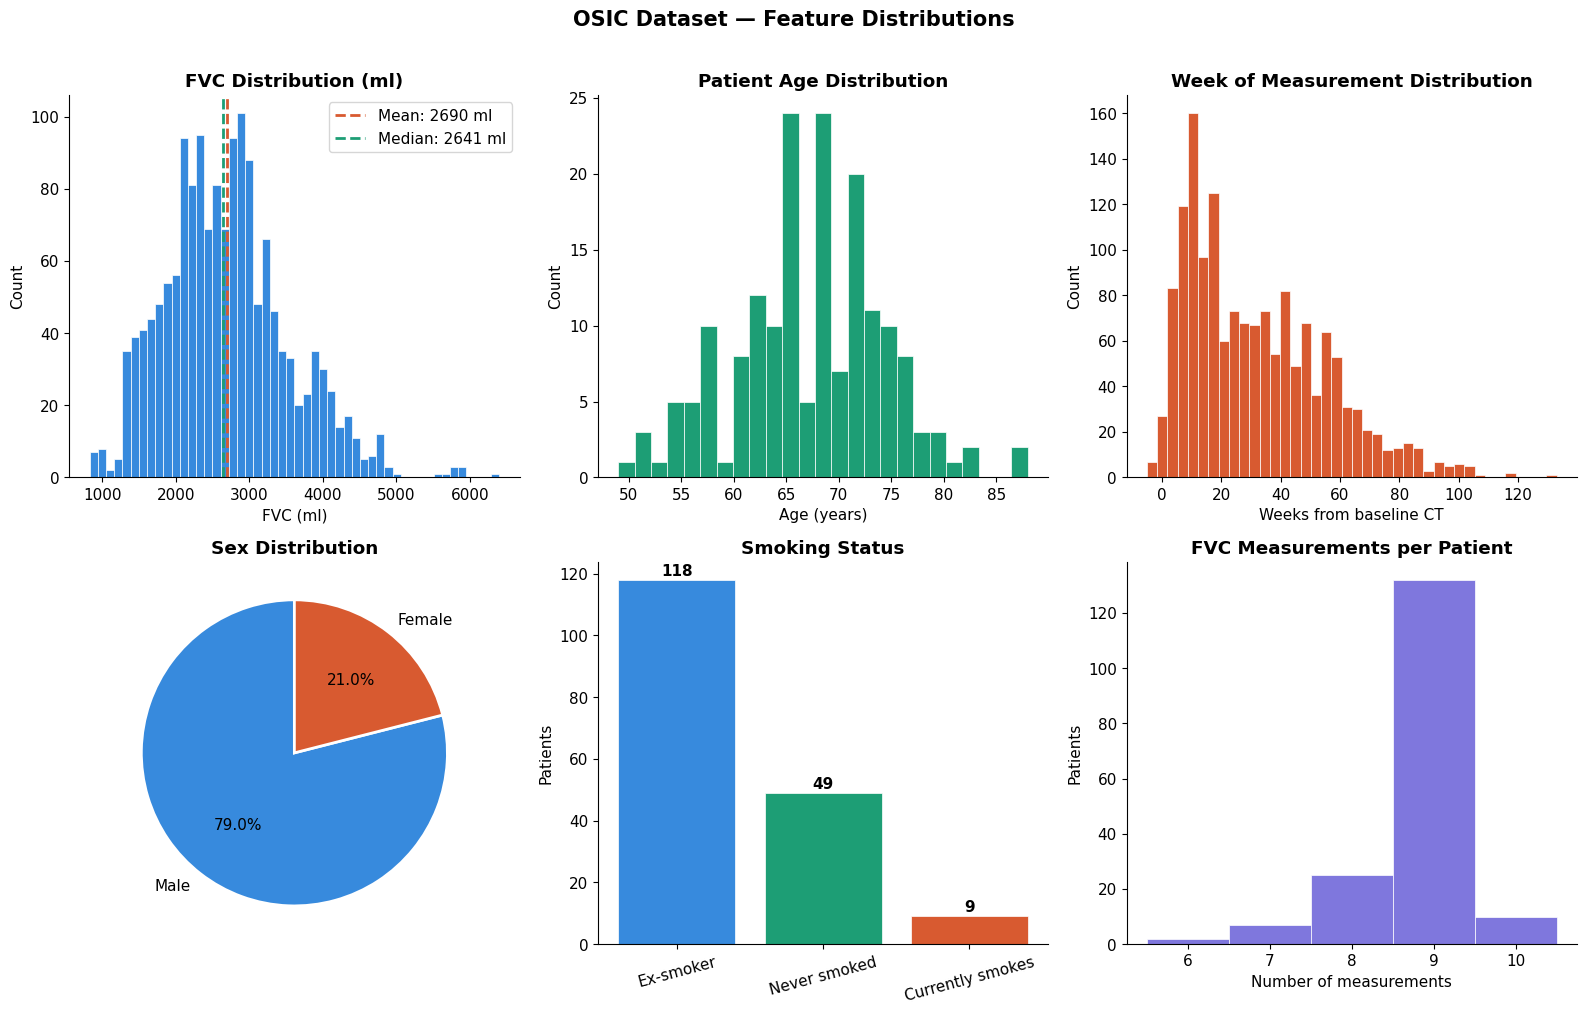

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("OSIC Dataset — Feature Distributions", fontsize=15, fontweight="bold", y=1.01)

# FVC distribution
axes[0,0].hist(train["FVC"], bins=50, color=BLUE, edgecolor="white", linewidth=0.5)
axes[0,0].axvline(train["FVC"].mean(), color=CORAL, linestyle="--", linewidth=2, label=f'Mean: {train["FVC"].mean():.0f} ml')
axes[0,0].axvline(train["FVC"].median(), color=TEAL, linestyle="--", linewidth=2, label=f'Median: {train["FVC"].median():.0f} ml')
axes[0,0].set_title("FVC Distribution (ml)", fontweight="bold")
axes[0,0].set_xlabel("FVC (ml)")
axes[0,0].set_ylabel("Count")
axes[0,0].legend()

# Age distribution
axes[0,1].hist(train.groupby("Patient")["Age"].first(), bins=25, color=TEAL, edgecolor="white", linewidth=0.5)
axes[0,1].set_title("Patient Age Distribution", fontweight="bold")
axes[0,1].set_xlabel("Age (years)")
axes[0,1].set_ylabel("Count")

# Weeks distribution
axes[0,2].hist(train["Weeks"], bins=40, color=CORAL, edgecolor="white", linewidth=0.5)
axes[0,2].set_title("Week of Measurement Distribution", fontweight="bold")
axes[0,2].set_xlabel("Weeks from baseline CT")
axes[0,2].set_ylabel("Count")

# Sex breakdown (pie)
sex_counts = train.groupby("Patient")["Sex"].first().value_counts()
axes[1,0].pie(sex_counts, labels=sex_counts.index, colors=[BLUE, CORAL],
              autopct="%1.1f%%", startangle=90, wedgeprops=dict(edgecolor="white", linewidth=2))
axes[1,0].set_title("Sex Distribution", fontweight="bold")

# Smoking status (bar)
smoke_counts = train.groupby("Patient")["SmokingStatus"].first().value_counts()
bars = axes[1,1].bar(smoke_counts.index, smoke_counts.values,
                      color=[BLUE, TEAL, CORAL], edgecolor="white", linewidth=0.5)
axes[1,1].set_title("Smoking Status", fontweight="bold")
axes[1,1].set_ylabel("Patients")
axes[1,1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, smoke_counts.values):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    str(val), ha='center', va='bottom', fontweight='bold')

# Measurements per patient
mpp = train.groupby("Patient")["Weeks"].count()
axes[1,2].hist(mpp, bins=range(mpp.min(), mpp.max()+2), color=PURPLE,
               edgecolor="white", linewidth=0.5, align='left')
axes[1,2].set_title("FVC Measurements per Patient", fontweight="bold")
axes[1,2].set_xlabel("Number of measurements")
axes[1,2].set_ylabel("Patients")

plt.tight_layout()
plt.savefig("outputs/01_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.3 FVC Trajectories — How Patients Progress Over Time

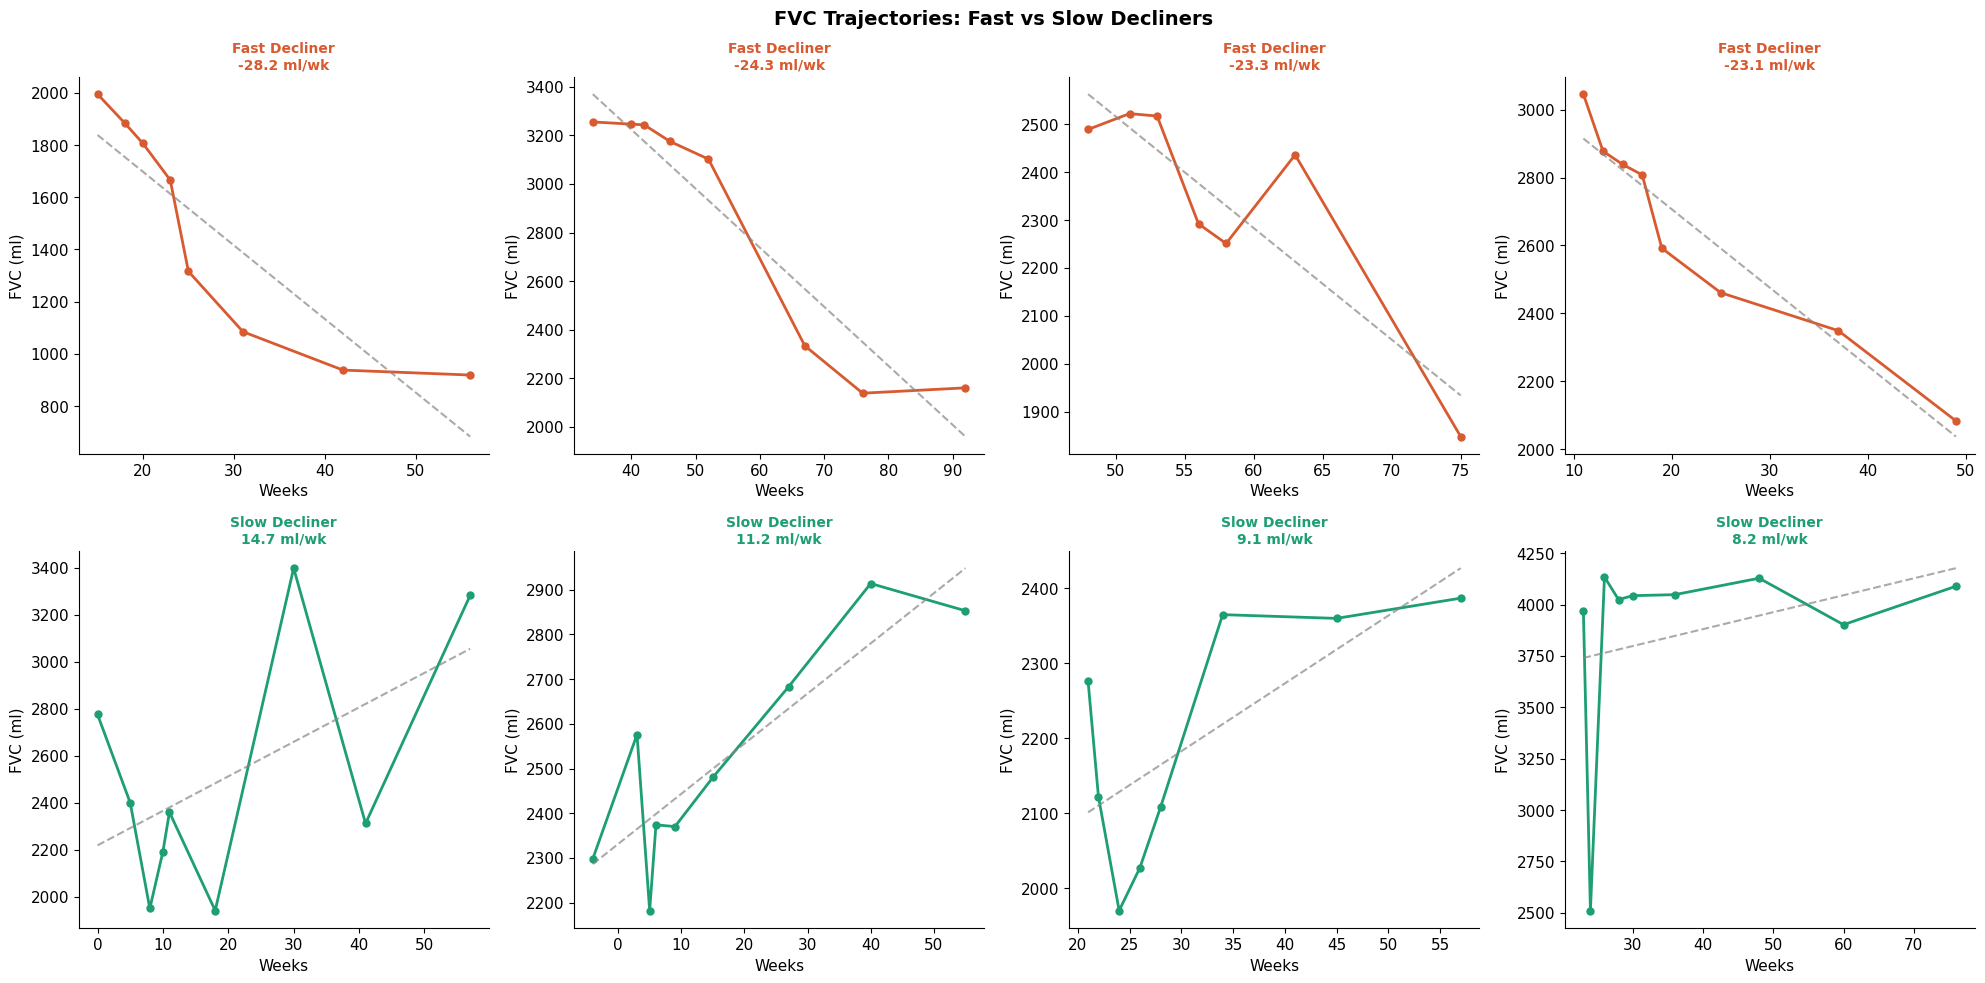


Slope summary (ml/week):
  Mean   : -4.52
  Median : -3.91
  Fastest decline : -28.18
  Most stable     : 14.68
  Declining patients: 147 / 176


In [22]:
# Compute FVC slope (ml/week) for each patient
def fvc_slope(group):
    g = group.sort_values("Weeks")
    if len(g) < 2:
        return np.nan
    return np.polyfit(g["Weeks"], g["FVC"], 1)[0]

slopes = train.groupby("Patient").apply(fvc_slope).dropna()

# Split into fast/slow decliners
fast_decliners = slopes.nsmallest(4).index.tolist()   # steepest negative slope
slow_decliners = slopes.nlargest(4).index.tolist()    # least negative / stable

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle("FVC Trajectories: Fast vs Slow Decliners", fontsize=14, fontweight="bold")

for i, pid in enumerate(fast_decliners):
    ax = axes[0, i]
    p = train[train["Patient"] == pid].sort_values("Weeks")
    ax.plot(p["Weeks"], p["FVC"], "o-", color=CORAL, linewidth=2, markersize=5)
    # Trend line
    z = np.polyfit(p["Weeks"], p["FVC"], 1)
    ax.plot(p["Weeks"], np.poly1d(z)(p["Weeks"]), "--", color=GRAY, linewidth=1.5, alpha=0.7)
    ax.set_title(f"Fast Decliner\n{slopes[pid]:.1f} ml/wk", fontsize=10, color=CORAL, fontweight="bold")
    ax.set_xlabel("Weeks")
    ax.set_ylabel("FVC (ml)")

for i, pid in enumerate(slow_decliners):
    ax = axes[1, i]
    p = train[train["Patient"] == pid].sort_values("Weeks")
    ax.plot(p["Weeks"], p["FVC"], "o-", color=TEAL, linewidth=2, markersize=5)
    z = np.polyfit(p["Weeks"], p["FVC"], 1)
    ax.plot(p["Weeks"], np.poly1d(z)(p["Weeks"]), "--", color=GRAY, linewidth=1.5, alpha=0.7)
    ax.set_title(f"Slow Decliner\n{slopes[pid]:.1f} ml/wk", fontsize=10, color=TEAL, fontweight="bold")
    ax.set_xlabel("Weeks")
    ax.set_ylabel("FVC (ml)")

plt.tight_layout()
plt.savefig("outputs/02_trajectories.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nSlope summary (ml/week):")
print(f"  Mean   : {slopes.mean():.2f}")
print(f"  Median : {slopes.median():.2f}")
print(f"  Fastest decline : {slopes.min():.2f}")
print(f"  Most stable     : {slopes.max():.2f}")
print(f"  Declining patients: {(slopes < 0).sum()} / {len(slopes)}")


### 3.4 FVC vs Clinical Features

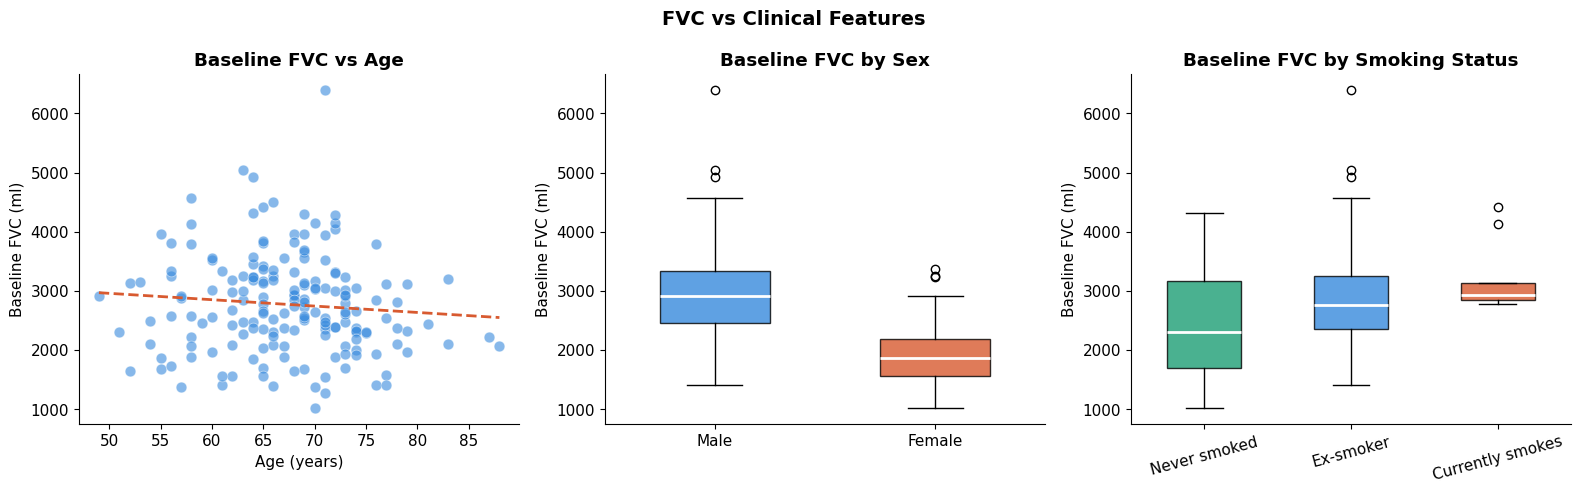

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("FVC vs Clinical Features", fontsize=14, fontweight="bold")

# FVC vs Age
patient_df = train.groupby("Patient").agg({"FVC": "first", "Age": "first", "Sex": "first", "SmokingStatus": "first"}).reset_index()
axes[0].scatter(patient_df["Age"], patient_df["FVC"], alpha=0.6, color=BLUE, s=60, edgecolors="white", linewidth=0.5)
z = np.polyfit(patient_df["Age"], patient_df["FVC"], 1)
x_line = np.linspace(patient_df["Age"].min(), patient_df["Age"].max(), 100)
axes[0].plot(x_line, np.poly1d(z)(x_line), color=CORAL, linewidth=2, linestyle="--")
axes[0].set_title("Baseline FVC vs Age", fontweight="bold")
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("Baseline FVC (ml)")

# FVC by Sex (boxplot)
male_fvc   = patient_df[patient_df["Sex"]=="Male"]["FVC"]
female_fvc = patient_df[patient_df["Sex"]=="Female"]["FVC"]
bp = axes[1].boxplot([male_fvc, female_fvc], labels=["Male", "Female"],
                      patch_artist=True, widths=0.5,
                      medianprops=dict(color="white", linewidth=2))
for patch, color in zip(bp["boxes"], [BLUE, CORAL]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[1].set_title("Baseline FVC by Sex", fontweight="bold")
axes[1].set_ylabel("Baseline FVC (ml)")

# FVC by smoking status (boxplot)
smoke_groups = [patient_df[patient_df["SmokingStatus"]==s]["FVC"]
                for s in ["Never smoked", "Ex-smoker", "Currently smokes"]
                if s in patient_df["SmokingStatus"].values]
smoke_labels = [s for s in ["Never smoked", "Ex-smoker", "Currently smokes"]
                if s in patient_df["SmokingStatus"].values]
bp2 = axes[2].boxplot(smoke_groups, labels=smoke_labels,
                       patch_artist=True, widths=0.5,
                       medianprops=dict(color="white", linewidth=2))
for patch, color in zip(bp2["boxes"], [TEAL, BLUE, CORAL]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[2].set_title("Baseline FVC by Smoking Status", fontweight="bold")
axes[2].set_ylabel("Baseline FVC (ml)")
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig("outputs/03_fvc_vs_features.png", dpi=150, bbox_inches="tight")
plt.show()


### 3.5 Disease Progression Rate Distribution

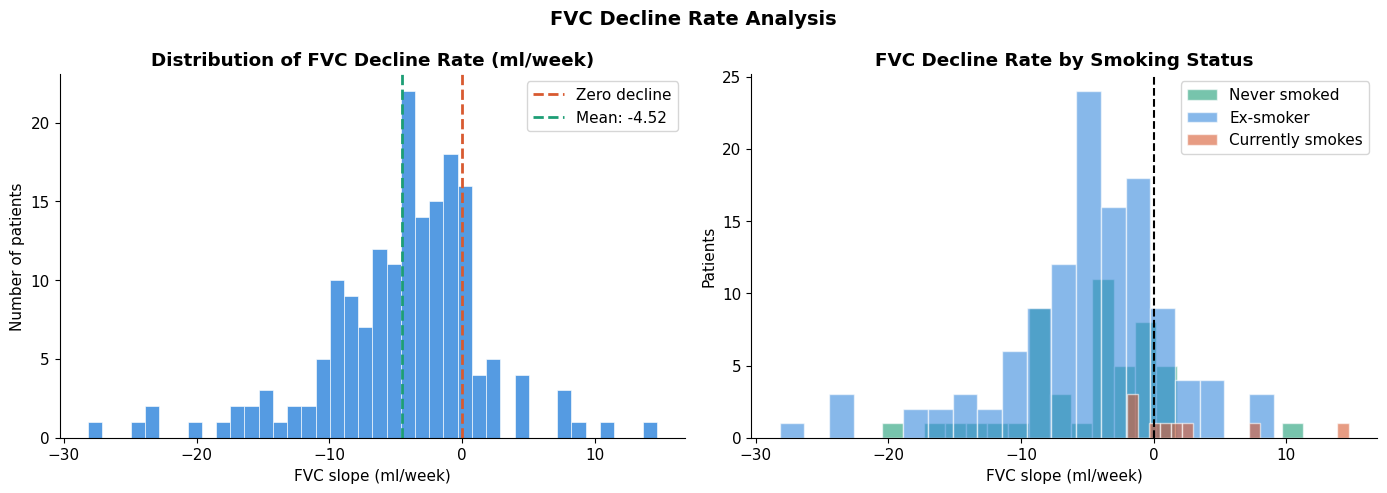

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("FVC Decline Rate Analysis", fontsize=14, fontweight="bold")

# Slope histogram
axes[0].hist(slopes, bins=40, color=BLUE, edgecolor="white", linewidth=0.5, alpha=0.85)
axes[0].axvline(0, color=CORAL, linewidth=2, linestyle="--", label="Zero decline")
axes[0].axvline(slopes.mean(), color=TEAL, linewidth=2, linestyle="--", label=f"Mean: {slopes.mean():.2f}")
axes[0].set_title("Distribution of FVC Decline Rate (ml/week)", fontweight="bold")
axes[0].set_xlabel("FVC slope (ml/week)")
axes[0].set_ylabel("Number of patients")
axes[0].legend()

# Slope by smoking status
for smoke, color in zip(["Never smoked", "Ex-smoker", "Currently smokes"], [TEAL, BLUE, CORAL]):
    pids = patient_df[patient_df["SmokingStatus"]==smoke]["Patient"]
    s = slopes[slopes.index.isin(pids)]
    if len(s) > 0:
        axes[1].hist(s, bins=20, alpha=0.6, color=color, edgecolor="white", label=smoke)
axes[1].axvline(0, color="black", linewidth=1.5, linestyle="--")
axes[1].set_title("FVC Decline Rate by Smoking Status", fontweight="bold")
axes[1].set_xlabel("FVC slope (ml/week)")
axes[1].set_ylabel("Patients")
axes[1].legend()

plt.tight_layout()
plt.savefig("outputs/04_decline_rates.png", dpi=150, bbox_inches="tight")
plt.show()


### 3.6 Feature Correlation Heatmap

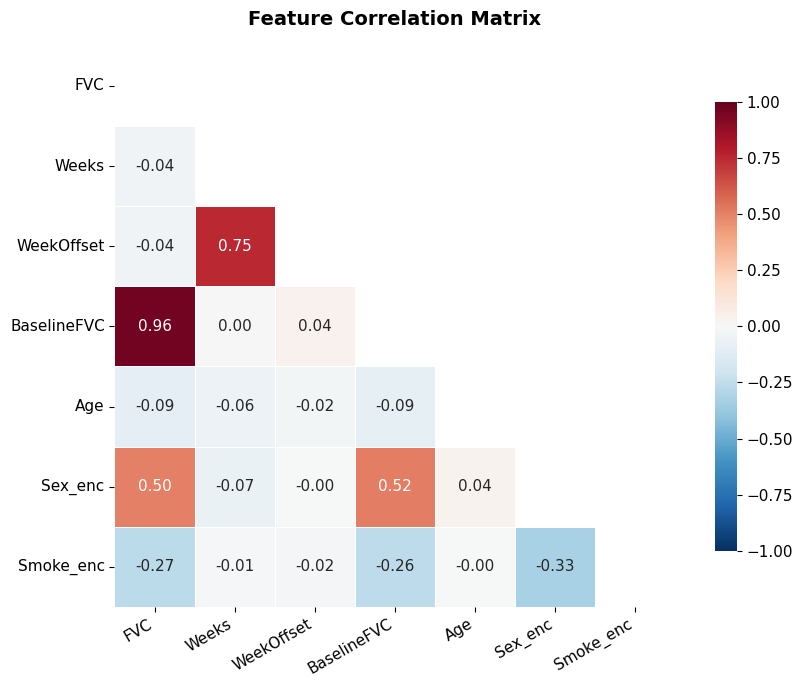


Key findings:
  FVC ~ BaselineFVC : 0.963  (strongest predictor)
  FVC ~ Weeks       : -0.041       (time effect)
  FVC ~ Age         : -0.094       (older → lower FVC)


In [25]:
from sklearn.preprocessing import LabelEncoder

corr_df = train.copy()
corr_df["Sex_enc"]    = LabelEncoder().fit_transform(corr_df["Sex"])
corr_df["Smoke_enc"]  = LabelEncoder().fit_transform(corr_df["SmokingStatus"])
corr_df["WeekOffset"] = corr_df.groupby("Patient")["Weeks"].transform(lambda x: x - x.min())
corr_df["BaselineFVC"]= corr_df.groupby("Patient")["FVC"].transform("first")

cols = ["FVC", "Weeks", "WeekOffset", "BaselineFVC", "Age", "Sex_enc", "Smoke_enc"]
corr_matrix = corr_df[cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, ax=ax, mask=mask, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold", pad=15)
ax.set_xticklabels(cols, rotation=30, ha='right')
ax.set_yticklabels(cols, rotation=0)
plt.tight_layout()
plt.savefig("outputs/05_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nKey findings:")
print(f"  FVC ~ BaselineFVC : {corr_matrix.loc['FVC','BaselineFVC']:.3f}  (strongest predictor)")
print(f"  FVC ~ Weeks       : {corr_matrix.loc['FVC','Weeks']:.3f}       (time effect)")
print(f"  FVC ~ Age         : {corr_matrix.loc['FVC','Age']:.3f}       (older → lower FVC)")


## 4. Feature Engineering

In [26]:
def prepare_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Engineer features for the tabular baseline model.
    No Percent feature — 1st place Kaggle winner found it hurts performance.
    """
    df = df.copy()

    # Categorical encoding (fixed mapping, not fit_transform)
    df["Sex_enc"]     = (df["Sex"] == "Male").astype(float)
    df["Smoking_enc"] = df["SmokingStatus"].map({
        "Never smoked":     0.0,
        "Ex-smoker":        1.0,
        "Currently smokes": 2.0
    }).fillna(0.0)

    # Temporal features
    df["BaselineFVC"]  = df.groupby("Patient")["FVC"].transform("first")
    df["BaselineWeek"] = df.groupby("Patient")["Weeks"].transform("first")
    df["WeekDelta"]    = df["Weeks"] - df["BaselineWeek"]

    return df

train = prepare_features(train)
test  = prepare_features(test)

FEATURES = ["WeekDelta", "BaselineFVC", "Age", "Sex_enc", "Smoking_enc"]

print("Features used:", FEATURES)
print()
print("Sample engineered features:")
display(train[["Patient", "Weeks", "WeekDelta", "BaselineFVC", "Sex_enc", "Smoking_enc", "FVC"]].head(8))


Features used: ['WeekDelta', 'BaselineFVC', 'Age', 'Sex_enc', 'Smoking_enc']

Sample engineered features:


,Patient,Weeks,WeekDelta,BaselineFVC,Sex_enc,Smoking_enc,FVC
0,ID00007637202177411956430,-4,0,2315,1.0,1.0,2315
1,ID00007637202177411956430,5,9,2315,1.0,1.0,2214
2,ID00007637202177411956430,7,11,2315,1.0,1.0,2061
3,ID00007637202177411956430,9,13,2315,1.0,1.0,2144
4,ID00007637202177411956430,11,15,2315,1.0,1.0,2069
5,ID00007637202177411956430,17,21,2315,1.0,1.0,2101
6,ID00007637202177411956430,29,33,2315,1.0,1.0,2000
7,ID00007637202177411956430,41,45,2315,1.0,1.0,2064


## 5. Loss Function — Modified Laplace Log-Likelihood

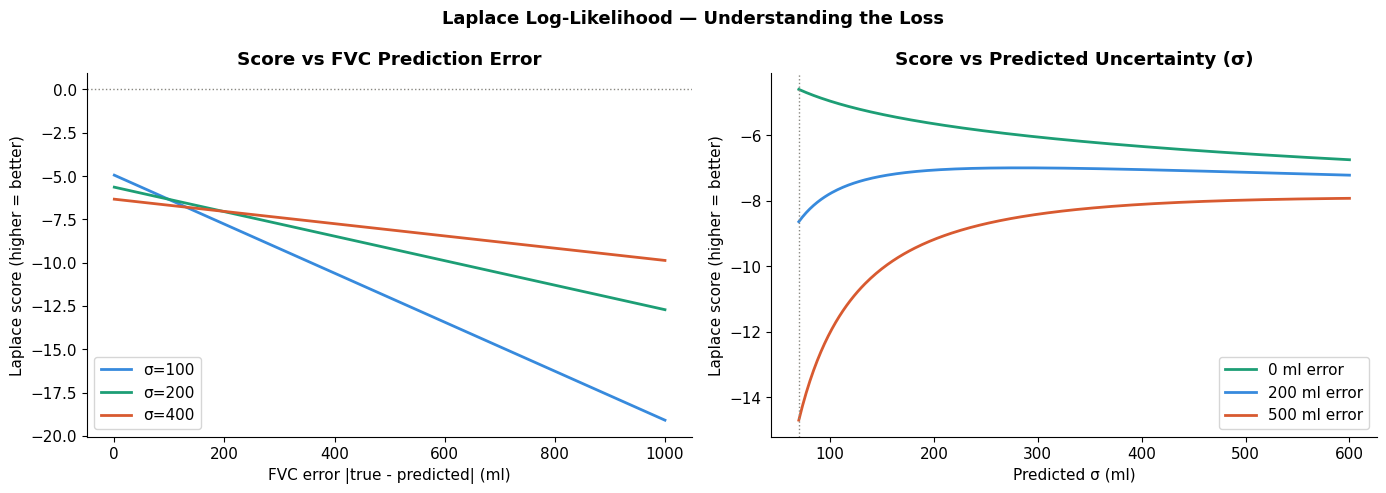

✓ Loss function verified and visualised


In [27]:
def laplace_nll(mu: torch.Tensor, sigma: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    """
    Modified Laplace Negative Log-Likelihood — the OSIC competition metric.

    Minimising this trains the model to:
      1. Predict accurate FVC values (mu)
      2. Predict well-calibrated uncertainty (sigma)

    Clipping rules:
      - FVC error clipped to 1000 ml (avoids outliers dominating)
      - Sigma clipped to min 70 ml (spirometry measurement noise floor)
    """
    delta = (y - mu).abs().clamp(max=1000.0)
    sigma_c = sigma.clamp(min=70.0)
    loss = (delta * 1.41421 / sigma_c) + torch.log(sigma_c * 1.41421)
    return loss.mean()

def laplace_metric(mu: np.ndarray, sigma: np.ndarray, y: np.ndarray) -> float:
    """Numpy version — returns competition score (higher/less negative = better)."""
    sigma = np.clip(sigma, 70, None)
    delta = np.clip(np.abs(y - mu), 0, 1000)
    return (-(delta * 1.41421 / sigma) - np.log(sigma * 1.41421)).mean()

# ── Visualise what the loss surface looks like ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Laplace Log-Likelihood — Understanding the Loss", fontsize=13, fontweight="bold")

# Score vs FVC error for different sigma values
errors = np.linspace(0, 1000, 300)
for sig, color, lbl in [(100, BLUE, "σ=100"), (200, TEAL, "σ=200"), (400, CORAL, "σ=400")]:
    scores = -(errors * 1.41421 / sig) - np.log(sig * 1.41421)
    axes[0].plot(errors, scores, color=color, linewidth=2, label=lbl)
axes[0].set_title("Score vs FVC Prediction Error", fontweight="bold")
axes[0].set_xlabel("FVC error |true - predicted| (ml)")
axes[0].set_ylabel("Laplace score (higher = better)")
axes[0].legend()
axes[0].axhline(0, color=GRAY, linewidth=1, linestyle=":")

# Score vs sigma (when error = 0, 200, 500 ml)
sigmas = np.linspace(70, 600, 300)
for err, color, lbl in [(0, TEAL, "0 ml error"), (200, BLUE, "200 ml error"), (500, CORAL, "500 ml error")]:
    err_c = min(err, 1000)
    scores = -(err_c * 1.41421 / sigmas) - np.log(sigmas * 1.41421)
    axes[1].plot(sigmas, scores, color=color, linewidth=2, label=lbl)
axes[1].set_title("Score vs Predicted Uncertainty (σ)", fontweight="bold")
axes[1].set_xlabel("Predicted σ (ml)")
axes[1].set_ylabel("Laplace score (higher = better)")
axes[1].legend()
axes[1].axvline(70, color=GRAY, linewidth=1, linestyle=":", label="σ min = 70")

plt.tight_layout()
plt.savefig("outputs/06_loss_surface.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Loss function verified and visualised")


## 6. Baseline Model — QuantileNet MLP

In [28]:
class FVCDataset(Dataset):
    """PyTorch dataset for tabular FVC features."""
    def __init__(self, df: pd.DataFrame):
        self.X   = torch.tensor(df[FEATURES].values, dtype=torch.float32)
        self.fvc = torch.tensor(df["FVC"].values,    dtype=torch.float32)
        # Normalise inputs
        self.mean = self.X.mean(0)
        self.std  = self.X.std(0).clamp(min=1e-6)

    def normalise(self, x):
        return (x - self.mean) / self.std

    def __len__(self):  return len(self.fvc)

    def __getitem__(self, i):
        return self.normalise(self.X[i]), self.fvc[i]


class QuantileNet(nn.Module):
    """
    3-layer MLP that jointly predicts:
      mu    — expected FVC (ml)
      sigma — uncertainty / confidence (ml)

    Architecture:
      Input(5) → Linear(256) → SiLU → Dropout(0.3)
               → Linear(256) → SiLU → Dropout(0.3)
               → Linear(128) → SiLU
               → [mu_head, sigma_head] → (mu, sigma)

    sigma uses softplus + 70 to ensure it stays ≥ 70 ml
    and gradients flow through (unlike hard clamp).
    """
    def __init__(self, in_dim: int = 5, hidden: int = 256):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.SiLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden, hidden // 2),
            nn.SiLU(),
        )
        self.mu_head    = nn.Linear(hidden // 2, 1)
        self.sigma_head = nn.Linear(hidden // 2, 1)

        # Initialise sigma head to predict ~200 ml from start
        nn.init.zeros_(self.sigma_head.weight)
        nn.init.constant_(self.sigma_head.bias, 5.3)   # softplus(5.3) + 70 ≈ 270 ml

        # Initialise mu head to predict near mean FVC (~3000 ml / 4000 scale)
        nn.init.zeros_(self.mu_head.weight)
        nn.init.constant_(self.mu_head.bias, 0.75)

    def forward(self, x: torch.Tensor):
        h     = self.backbone(x)
        mu    = self.mu_head(h).squeeze(1) * 4000.0
        sigma = nn.functional.softplus(self.sigma_head(h).squeeze(1)) + 70.0
        return mu, sigma


# ── Quick architecture summary ───────────────────────────────────────────────
model_demo = QuantileNet()
total_params = sum(p.numel() for p in model_demo.parameters())
print("QuantileNet Architecture:")
print(model_demo)
print(f"\nTotal parameters: {total_params:,}")

# Quick forward pass sanity check
dummy = torch.randn(4, 5)
mu_d, sigma_d = model_demo(dummy)
print(f"\nSanity check — batch of 4:")
print(f"  mu    : {mu_d.detach().numpy().round(0)}  (should be ~3000 ml)")
print(f"  sigma : {sigma_d.detach().numpy().round(1)}  (should be ~200 ml)")
print("✓ Model instantiated correctly")


QuantileNet Architecture:
QuantileNet(
  (backbone): Sequential(
    (0): Linear(in_features=5, out_features=256, bias=True)
    (1): SiLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): SiLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): SiLU()
  )
  (mu_head): Linear(in_features=128, out_features=1, bias=True)
  (sigma_head): Linear(in_features=128, out_features=1, bias=True)
)

Total parameters: 100,482

Sanity check — batch of 4:
  mu    : [3000. 3000. 3000. 3000.]  (should be ~3000 ml)
  sigma : [75.3 75.3 75.3 75.3]  (should be ~200 ml)
✓ Model instantiated correctly


## 7. Training — 5-Fold Cross Validation

In [29]:
def set_seed(seed=42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True   # full reproducibility
    torch.backends.cudnn.benchmark     = False

set_seed(42)

DEVICE    = "cuda" if torch.cuda.is_available() else "cpu"
N_SPLITS  = 5
EPOCHS    = 500
LR        = 1e-3
BATCH     = 128
PATIENCE  = 50       # early stopping — stop if no improvement for 50 checks
EVAL_EVERY = 10      # evaluate every N epochs (was 50 — now faster feedback)

os.makedirs("outputs/checkpoints", exist_ok=True)

patients = train["Patient"].unique()

# ── GroupKFold: guarantees each patient is in exactly one fold ──────────────
gkf = GroupKFold(n_splits=N_SPLITS)

oof_mu    = np.zeros(len(train))
oof_sigma = np.zeros(len(train))
fold_scores = []
history     = []   # for learning curve plot

print(f"Device : {DEVICE}")
print(f"Folds  : {N_SPLITS}  |  Epochs: {EPOCHS}  |  Patients: {len(patients)}")
print(f"Early stopping patience: {PATIENCE} evaluations (={PATIENCE * EVAL_EVERY} epochs)")
print("="*65)

for fold, (tr_idx, val_idx) in enumerate(gkf.split(
        np.zeros(len(patients)),         # X (dummy)
        groups=patients                  # group labels = patient IDs
)):
    tr_pats  = set(patients[tr_idx])
    val_pats = set(patients[val_idx])

    tr_df    = train[train["Patient"].isin(tr_pats)].reset_index(drop=True)
    val_df   = train[train["Patient"].isin(val_pats)].reset_index(drop=True)
    val_mask = train["Patient"].isin(val_pats)

    tr_ds  = FVCDataset(tr_df)
    val_ds = FVCDataset(val_df)
    # Share normalisation stats from training set
    val_ds.mean = tr_ds.mean
    val_ds.std  = tr_ds.std

    tr_dl  = DataLoader(tr_ds,  batch_size=BATCH, shuffle=True,  drop_last=False)
    val_dl = DataLoader(val_ds, batch_size=256,   shuffle=False)

    model = QuantileNet(in_dim=len(FEATURES)).to(DEVICE)
    opt   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS, eta_min=1e-5)

    best_score, best_mu, best_sigma = -999, None, None
    patience_counter = 0
    fold_history = []

    for epoch in range(EPOCHS):
        # ── Training step ──────────────────────────────────────────────────
        model.train()
        for xb, yb in tr_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            mu, sigma = model(xb)
            loss = laplace_nll(mu, sigma, yb)
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        sched.step()

        # ── Validation step (every EVAL_EVERY epochs) ──────────────────────
        if (epoch + 1) % EVAL_EVERY == 0:
            model.eval()
            all_mu, all_sigma, all_y = [], [], []
            with torch.no_grad():
                for xb, yb in val_dl:
                    m, s = model(xb.to(DEVICE))
                    all_mu.append(m.cpu())
                    all_sigma.append(s.cpu())
                    all_y.append(yb)
            all_mu    = torch.cat(all_mu).numpy()
            all_sigma = torch.cat(all_sigma).numpy()
            all_y     = torch.cat(all_y).numpy()
            score = laplace_metric(all_mu, all_sigma, all_y)
            fold_history.append((epoch+1, score))

            if score > best_score:
                best_score, best_mu, best_sigma = score, all_mu.copy(), all_sigma.copy()
                # ── Save best checkpoint for this fold ───────────────────
                torch.save({
                    "epoch":        epoch + 1,
                    "model_state":  model.state_dict(),
                    "score":        best_score,
                    "norm_mean":    tr_ds.mean,
                    "norm_std":     tr_ds.std,
                }, f"outputs/checkpoints/fold{fold+1}_best.pt")
                patience_counter = 0
            else:
                patience_counter += 1

            # ── Early stopping ────────────────────────────────────────────
            if patience_counter >= PATIENCE:
                print(f"  Early stop at epoch {epoch+1} (no improvement for {PATIENCE} checks)")
                break

    oof_mu[val_mask]    = best_mu
    oof_sigma[val_mask] = best_sigma
    fold_scores.append(best_score)
    history.append(fold_history)

    print(f"Fold {fold+1} | best score: {best_score:.4f} | "
          f"mu: {best_mu.min():.0f}–{best_mu.max():.0f} | "
          f"sigma mean: {best_sigma.mean():.1f} ml")

overall = laplace_metric(oof_mu, oof_sigma, train["FVC"].values)
print("="*65)
print(f"Overall OOF Laplace score : {overall:.4f}")
print(f"Fold std                  : {np.std(fold_scores):.4f}")
print()
print("Context:")
print(f"  Our tabular baseline    : {overall:.4f}")
print(f"  Best published (FVC-Net): -6.6414")
print(f"  Kaggle 1st place        : -6.63")
print(f"  Gap to close with CT    : {overall - (-6.6414):+.4f}")

# ── Save results to JSON for experiment tracking ─────────────────────────────
import json as _json
results_dict = {
    "model":         "QuantileNet",
    "features":      FEATURES,
    "n_splits":      N_SPLITS,
    "epochs":        EPOCHS,
    "oof_score":     float(overall),
    "fold_scores":   [float(s) for s in fold_scores],
    "fold_std":      float(np.std(fold_scores)),
    "mae":           float(np.abs(train["FVC"].values - oof_mu).clip(0, 1000).mean()),
    "mean_sigma":    float(oof_sigma.mean()),
}
with open("outputs/phase1_results.json", "w") as f:
    _json.dump(results_dict, f, indent=2)
print("\n✓ Results saved → outputs/phase1_results.json")
print("✓ Fold checkpoints saved → outputs/checkpoints/fold*_best.pt")


Device : cuda
Folds  : 5  |  Epochs: 500  |  Patients: 176
Early stopping patience: 50 evaluations (=500 epochs)
Fold 1 | best score: -6.6409 | mu: 1275–4398 | sigma mean: 204.0 ml
Fold 2 | best score: -6.7129 | mu: 1301–4947 | sigma mean: 198.7 ml
Fold 3 | best score: -6.4985 | mu: 1327–6178 | sigma mean: 216.6 ml
Fold 4 | best score: -6.7311 | mu: 1156–4103 | sigma mean: 204.8 ml
Fold 5 | best score: -6.7747 | mu: 1346–4465 | sigma mean: 206.3 ml
Overall OOF Laplace score : -6.6716
Fold std                  : 0.0967

Context:
  Our tabular baseline    : -6.6716
  Best published (FVC-Net): -6.6414
  Kaggle 1st place        : -6.63
  Gap to close with CT    : -0.0302

✓ Results saved → outputs/phase1_results.json
✓ Fold checkpoints saved → outputs/checkpoints/fold*_best.pt


## 8. Results & Visualisation

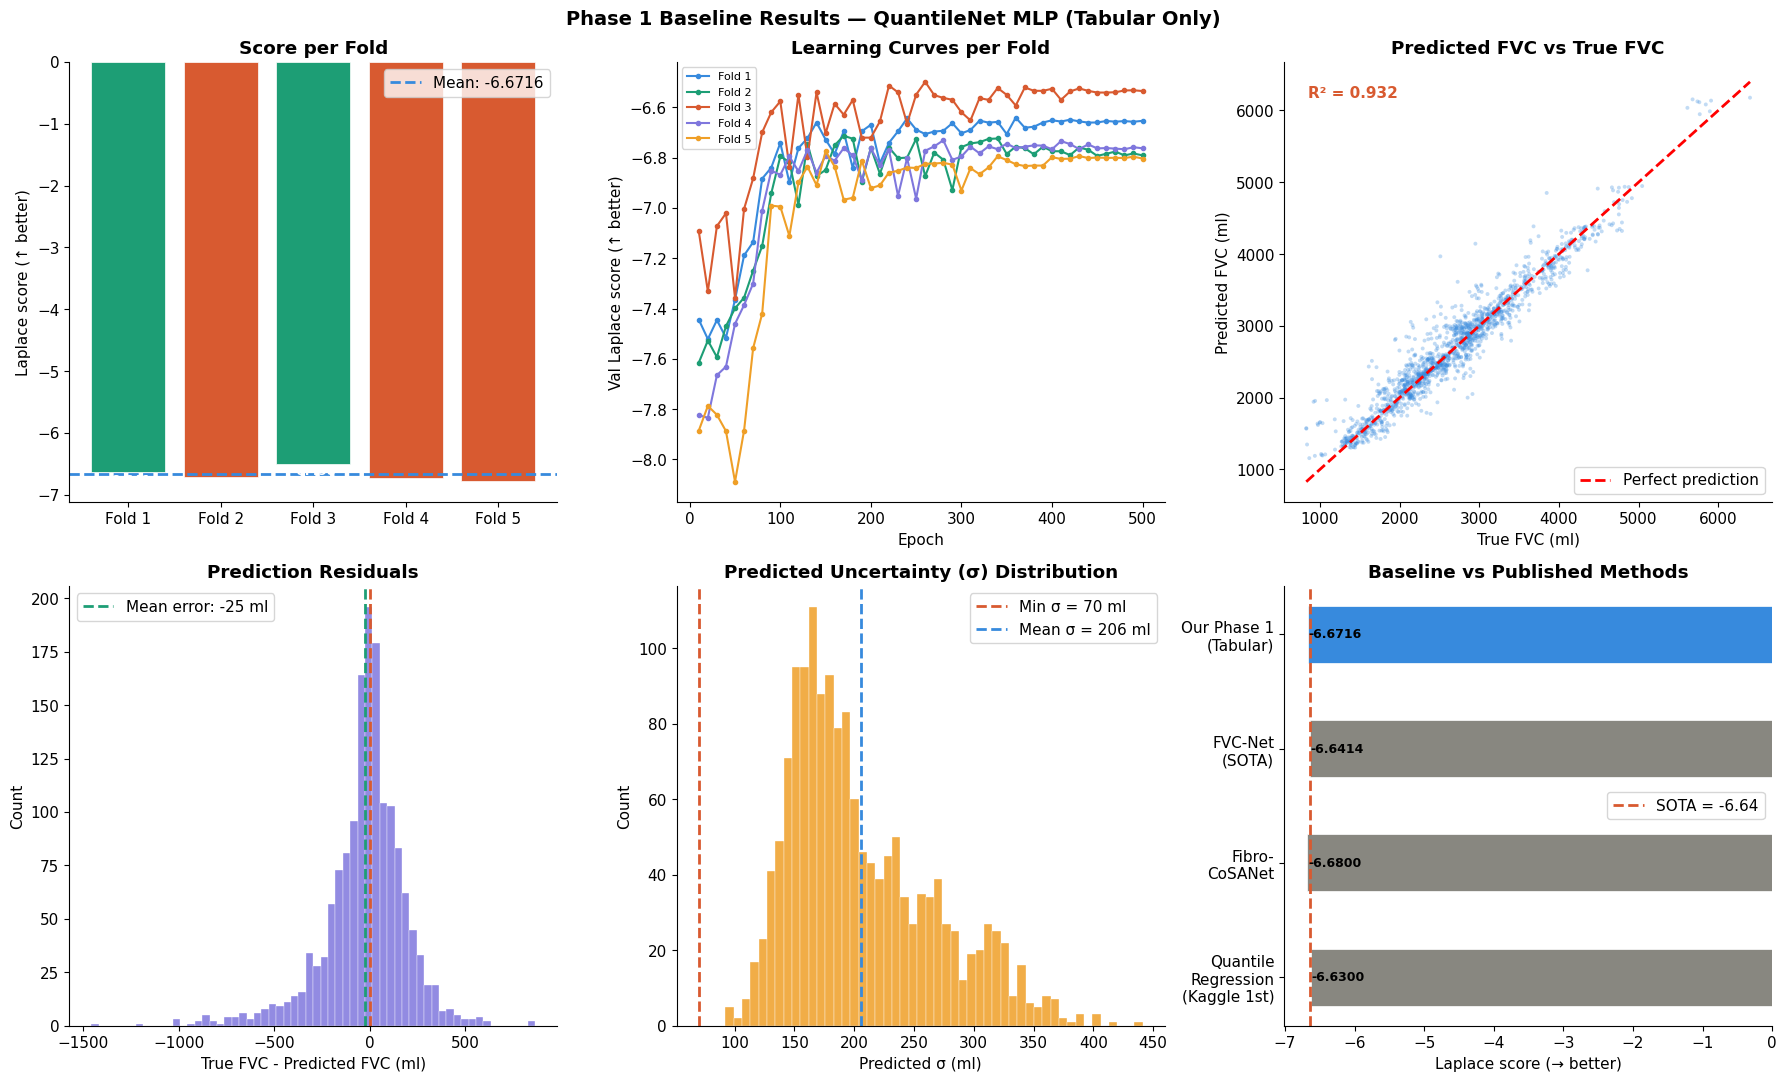

✓ Saved outputs/07_baseline_results.png


In [30]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Phase 1 Baseline Results — QuantileNet MLP (Tabular Only)", fontsize=14, fontweight="bold")

# 1. Fold scores bar chart
colors_bar = [TEAL if s > overall else CORAL for s in fold_scores]
bars = axes[0,0].bar([f"Fold {i+1}" for i in range(N_SPLITS)], fold_scores, color=colors_bar, edgecolor="white", linewidth=0.5)
axes[0,0].axhline(overall, color=BLUE, linewidth=2, linestyle="--", label=f"Mean: {overall:.4f}")
axes[0,0].set_title("Score per Fold", fontweight="bold")
axes[0,0].set_ylabel("Laplace score (↑ better)")
axes[0,0].legend()
for bar, val in zip(bars, fold_scores):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.02,
                    f"{val:.3f}", ha='center', va='top', fontsize=9, color="white", fontweight="bold")

# 2. Learning curves per fold
for fi, fh in enumerate(history):
    epochs_h, scores_h = zip(*fh)
    axes[0,1].plot(epochs_h, scores_h, marker='o', markersize=3, linewidth=1.5,
                    label=f"Fold {fi+1}", color=PALETTE[fi % len(PALETTE)])
axes[0,1].set_title("Learning Curves per Fold", fontweight="bold")
axes[0,1].set_xlabel("Epoch")
axes[0,1].set_ylabel("Val Laplace score (↑ better)")
axes[0,1].legend(fontsize=8)

# 3. Predicted vs True FVC
axes[0,2].scatter(train["FVC"], oof_mu, alpha=0.3, s=8, color=BLUE, edgecolors="none")
mn, mx = train["FVC"].min(), train["FVC"].max()
axes[0,2].plot([mn, mx], [mn, mx], "r--", linewidth=2, label="Perfect prediction")
axes[0,2].set_title("Predicted FVC vs True FVC", fontweight="bold")
axes[0,2].set_xlabel("True FVC (ml)")
axes[0,2].set_ylabel("Predicted FVC (ml)")
axes[0,2].legend()
r2 = np.corrcoef(train["FVC"], oof_mu)[0,1]**2
axes[0,2].text(0.05, 0.92, f"R² = {r2:.3f}", transform=axes[0,2].transAxes, fontsize=11,
                color=CORAL, fontweight="bold")

# 4. Residuals distribution
residuals = train["FVC"].values - oof_mu
axes[1,0].hist(residuals, bins=60, color=PURPLE, edgecolor="white", linewidth=0.3, alpha=0.85)
axes[1,0].axvline(0, color=CORAL, linewidth=2, linestyle="--")
axes[1,0].axvline(residuals.mean(), color=TEAL, linewidth=2, linestyle="--",
                   label=f"Mean error: {residuals.mean():.0f} ml")
axes[1,0].set_title("Prediction Residuals", fontweight="bold")
axes[1,0].set_xlabel("True FVC - Predicted FVC (ml)")
axes[1,0].set_ylabel("Count")
axes[1,0].legend()

# 5. Sigma (uncertainty) distribution
axes[1,1].hist(oof_sigma, bins=50, color=AMBER, edgecolor="white", linewidth=0.3, alpha=0.85)
axes[1,1].axvline(70, color=CORAL, linewidth=2, linestyle="--", label="Min σ = 70 ml")
axes[1,1].axvline(oof_sigma.mean(), color=BLUE, linewidth=2, linestyle="--",
                   label=f"Mean σ = {oof_sigma.mean():.0f} ml")
axes[1,1].set_title("Predicted Uncertainty (σ) Distribution", fontweight="bold")
axes[1,1].set_xlabel("Predicted σ (ml)")
axes[1,1].set_ylabel("Count")
axes[1,1].legend()

# 6. Score comparison bar chart
methods = ["Quantile\nRegression\n(Kaggle 1st)", "Fibro-\nCoSANet", "FVC-Net\n(SOTA)", "Our Phase 1\n(Tabular)"]
scores_compare = [-6.63, -6.68, -6.6414, overall]
colors_comp = [GRAY, GRAY, GRAY, BLUE]
bars2 = axes[1,2].barh(methods, scores_compare, color=colors_comp, edgecolor="white", linewidth=0.5, height=0.5)
axes[1,2].set_title("Baseline vs Published Methods", fontweight="bold")
axes[1,2].set_xlabel("Laplace score (→ better)")
axes[1,2].axvline(-6.6414, color=CORAL, linewidth=2, linestyle="--", label="SOTA = -6.64")
axes[1,2].legend()
for bar, val in zip(bars2, scores_compare):
    axes[1,2].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                    f"{val:.4f}", va='center', fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("outputs/07_baseline_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved outputs/07_baseline_results.png")


### 8.1 Error Analysis by Patient Subgroup

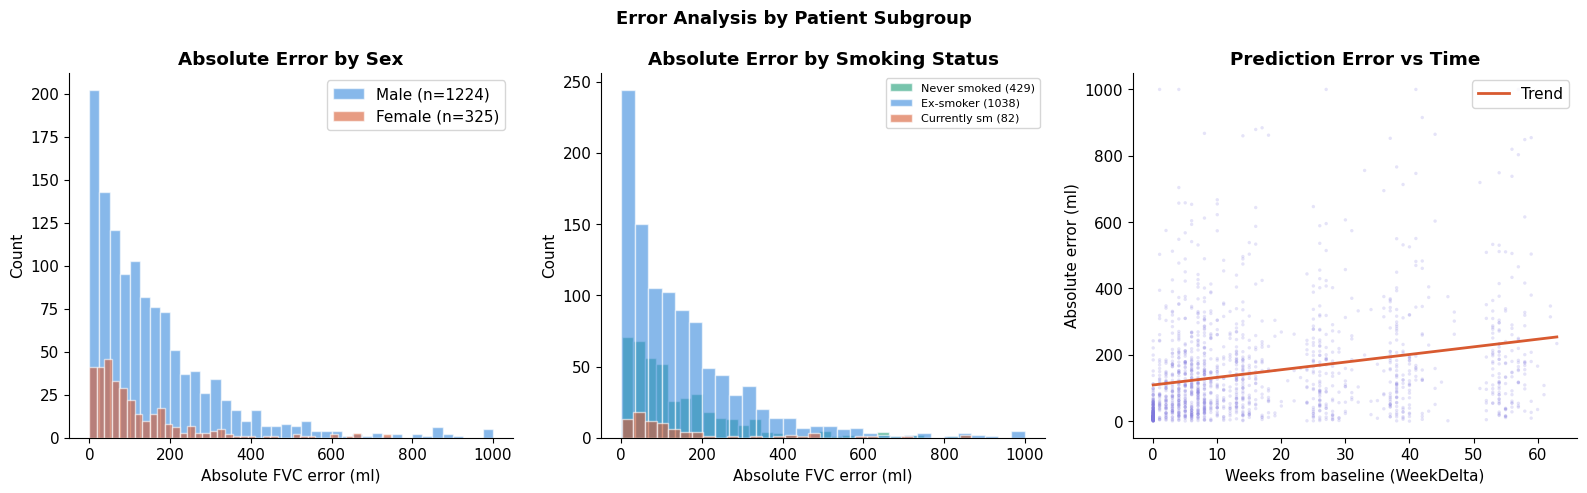

Error analysis summary:
  MAE overall             : 149.1 ml
  MAE Male patients       : 156.9 ml
  MAE Female patients     : 119.4 ml
  MAE early weeks (0-30)  : 131.9 ml
  MAE late weeks (>90)    : nan ml


In [31]:
# Add predictions back to dataframe
train["pred_mu"]    = oof_mu
train["pred_sigma"] = oof_sigma
train["abs_error"]  = np.abs(train["FVC"] - train["pred_mu"]).clip(0, 1000)
train["laplace"]    = -(train["abs_error"] * 1.41421 / train["pred_sigma"].clip(lower=70))                        - np.log(train["pred_sigma"].clip(lower=70) * 1.41421)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Error Analysis by Patient Subgroup", fontsize=13, fontweight="bold")

# Error by sex
for sex, color in zip(["Male", "Female"], [BLUE, CORAL]):
    sub = train[train["Sex"]==sex]["abs_error"]
    axes[0].hist(sub, bins=40, alpha=0.6, color=color, edgecolor="white", label=f"{sex} (n={len(sub)})")
axes[0].set_title("Absolute Error by Sex", fontweight="bold")
axes[0].set_xlabel("Absolute FVC error (ml)")
axes[0].set_ylabel("Count")
axes[0].legend()

# Error by smoking status
for smoke, color in zip(["Never smoked","Ex-smoker","Currently smokes"], [TEAL, BLUE, CORAL]):
    sub = train[train["SmokingStatus"]==smoke]["abs_error"]
    if len(sub) > 0:
        axes[1].hist(sub, bins=30, alpha=0.6, color=color, edgecolor="white", label=f"{smoke[:12]} ({len(sub)})")
axes[1].set_title("Absolute Error by Smoking Status", fontweight="bold")
axes[1].set_xlabel("Absolute FVC error (ml)")
axes[1].set_ylabel("Count")
axes[1].legend(fontsize=8)

# Error vs week delta (does error grow over time?)
axes[2].scatter(train["WeekDelta"], train["abs_error"], alpha=0.2, s=6, color=PURPLE, edgecolors="none")
z = np.polyfit(train["WeekDelta"], train["abs_error"], 1)
x_l = np.linspace(train["WeekDelta"].min(), train["WeekDelta"].max(), 100)
axes[2].plot(x_l, np.poly1d(z)(x_l), color=CORAL, linewidth=2, label="Trend")
axes[2].set_title("Prediction Error vs Time", fontweight="bold")
axes[2].set_xlabel("Weeks from baseline (WeekDelta)")
axes[2].set_ylabel("Absolute error (ml)")
axes[2].legend()

plt.tight_layout()
plt.savefig("outputs/08_error_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print("Error analysis summary:")
print(f"  MAE overall             : {train['abs_error'].mean():.1f} ml")
print(f"  MAE Male patients       : {train[train['Sex']=='Male']['abs_error'].mean():.1f} ml")
print(f"  MAE Female patients     : {train[train['Sex']=='Female']['abs_error'].mean():.1f} ml")
print(f"  MAE early weeks (0-30)  : {train[train['WeekDelta']<=30]['abs_error'].mean():.1f} ml")
print(f"  MAE late weeks (>90)    : {train[train['WeekDelta']>90]['abs_error'].mean():.1f} ml")


## 9. CT Scan Preprocessing — Caching Volumes for Phase 2

In [32]:
import pydicom
import SimpleITK as sitk
from tqdm import tqdm

HU_MIN         = -1000
HU_MAX         =  400
TARGET_SPACING = (1.5, 1.5, 1.5)

def load_dicom_volume(patient_dir):
    slices = []
    for f in sorted(Path(patient_dir).glob("*.dcm")):
        try:
            slices.append(pydicom.dcmread(str(f)))
        except:
            continue
    if not slices:
        raise ValueError(f"No DICOM files in {patient_dir}")
    slices.sort(key=lambda s: float(s.ImagePositionPatient[2]))
    volume = np.stack([
        s.pixel_array.astype(np.float32) * float(s.RescaleSlope) + float(s.RescaleIntercept)
        for s in slices
    ])
    spacing = (float(slices[0].SliceThickness),
               float(slices[0].PixelSpacing[0]),
               float(slices[0].PixelSpacing[1]))
    return volume, spacing

def resample_volume(volume, original_spacing):
    sitk_vol = sitk.GetImageFromArray(volume)
    sitk_vol.SetSpacing(list(reversed(original_spacing)))
    orig_size    = sitk_vol.GetSize()
    orig_spacing = sitk_vol.GetSpacing()
    new_size = [int(round(orig_size[i] * orig_spacing[i] / TARGET_SPACING[-(i+1)])) for i in range(3)]
    resampler = sitk.ResampleImageFilter()
    resampler.SetOutputSpacing(list(reversed(TARGET_SPACING)))
    resampler.SetSize(new_size)
    resampler.SetInterpolator(sitk.sitkLinear)
    resampler.SetOutputDirection(sitk_vol.GetDirection())
    resampler.SetOutputOrigin(sitk_vol.GetOrigin())
    resampler.SetDefaultPixelValue(HU_MIN)
    return sitk.GetArrayFromImage(resampler.Execute(sitk_vol)).astype(np.float32)

def window_normalize(volume):
    return ((volume.clip(HU_MIN, HU_MAX) - HU_MIN) / (HU_MAX - HU_MIN)).astype(np.float32)

def preprocess_all(dicom_root, output_root):
    os.makedirs(output_root, exist_ok=True)
    patient_dirs = sorted(Path(dicom_root).iterdir())
    ok, skip = 0, 0
    for p in tqdm(patient_dirs, desc="Preprocessing CT"):
        if not p.is_dir(): continue
        out = Path(output_root) / f"{p.name}.npy"
        if out.exists(): ok += 1; continue
        try:
            vol, sp = load_dicom_volume(str(p))
            vol = resample_volume(vol, sp)
            vol = window_normalize(vol)
            np.save(str(out), vol)
            ok += 1
        except Exception as e:
            skip += 1
    print(f"Processed: {ok}  |  Skipped: {skip}")

DICOM_TRAIN = f"{BASE}/train"
OUT_TRAIN   = "data/processed/train"

os.makedirs(OUT_TRAIN, exist_ok=True)
preprocess_all(DICOM_TRAIN, OUT_TRAIN)


Preprocessing CT: 100%|██████████| 176/176 [09:29<00:00,  3.24s/it]

Processed: 171  |  Skipped: 5


## 10. CT Scan Visualisation — Before and After Preprocessing

Total preprocessed volumes: 171
Visualising patient: ID00007637202177411956430
Raw shape    : (512, 512)  |  HU range: [-3024, 2105]
Processed    : (25, 223, 223)  |  Value range: [0.000, 1.000]


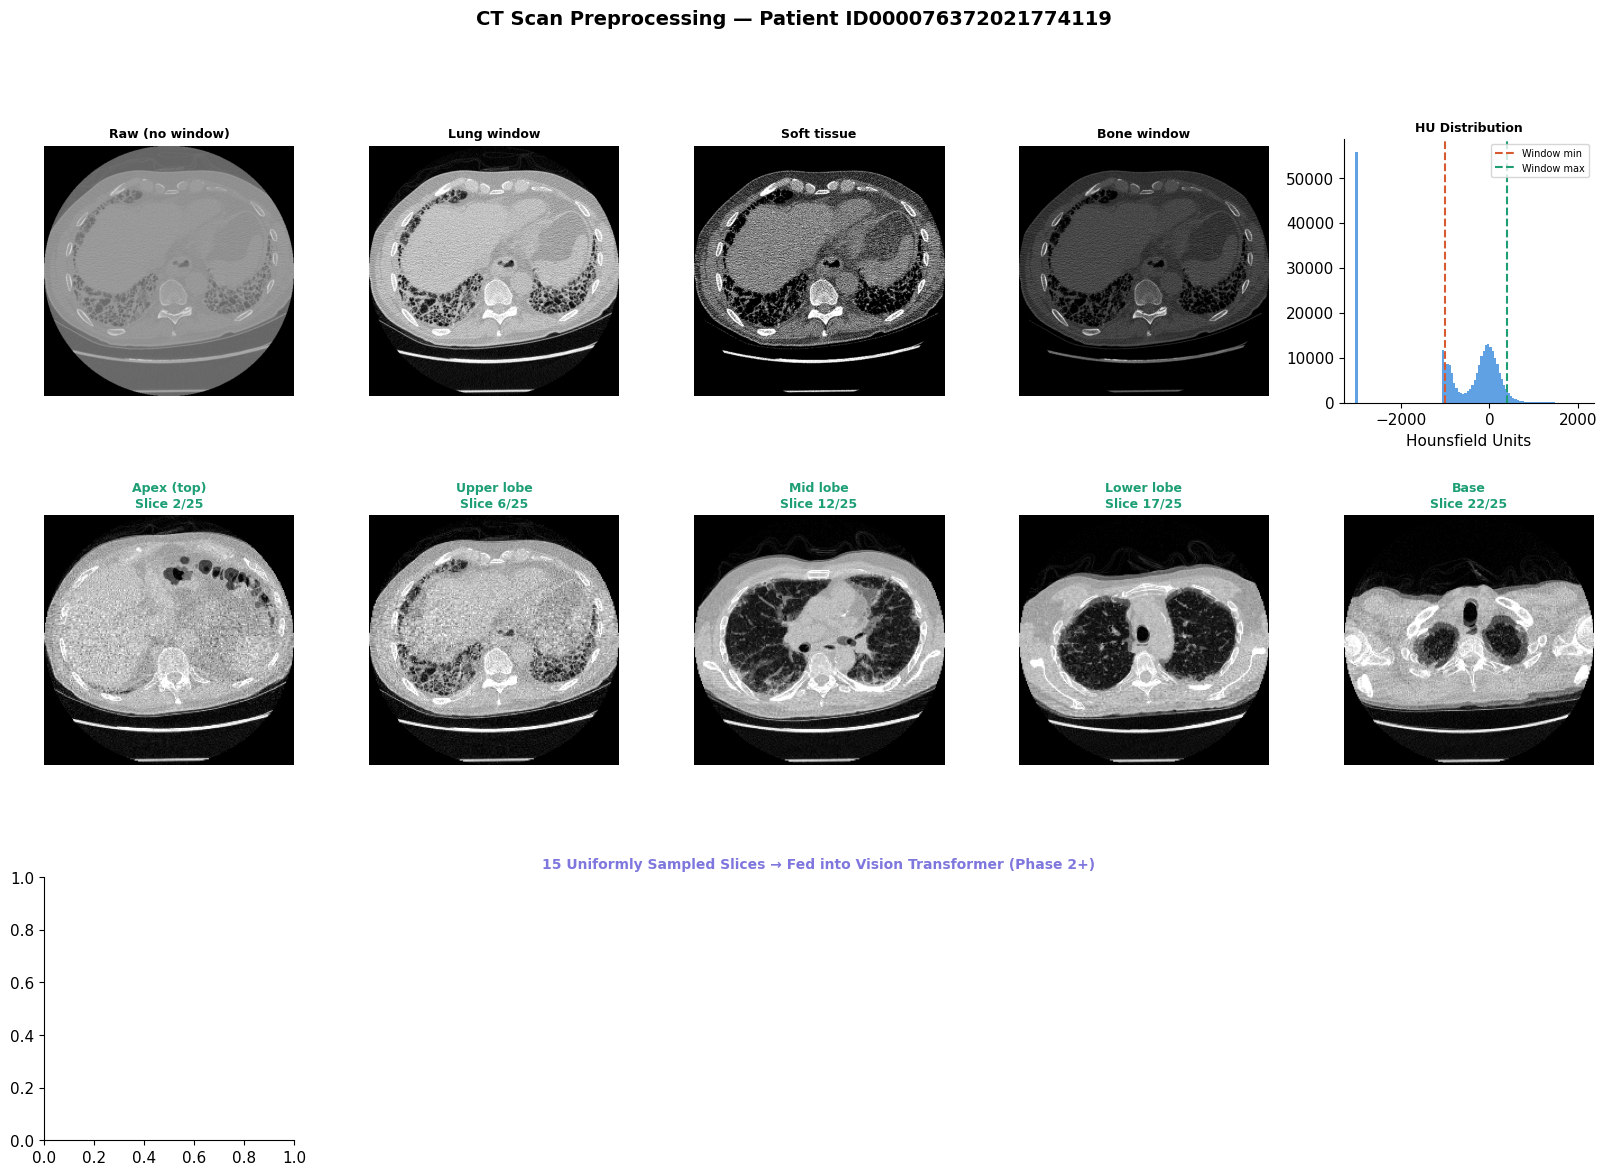

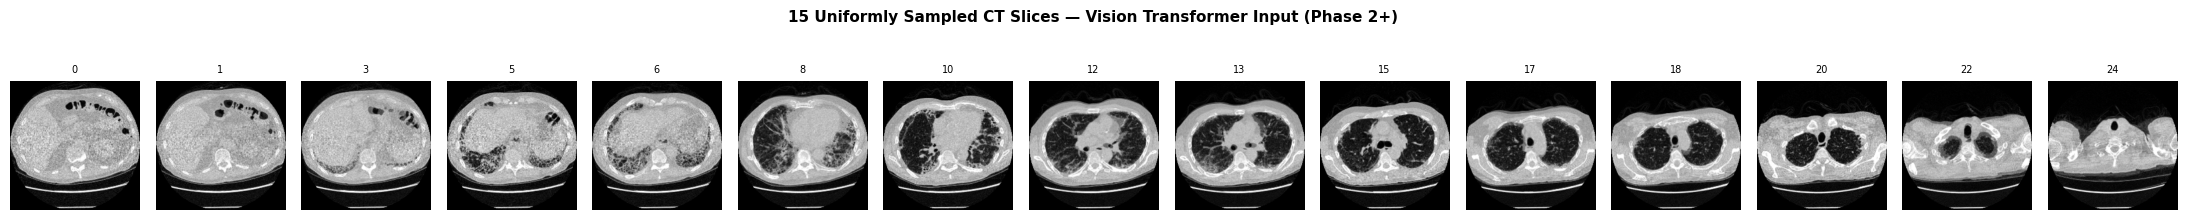

✓ CT visualisations saved


In [33]:
processed_vols = sorted(Path(OUT_TRAIN).glob("*.npy"))
print(f"Total preprocessed volumes: {len(processed_vols)}")

# Pick first successfully processed patient
sample_npy = processed_vols[0]
patient_id = sample_npy.stem
print(f"Visualising patient: {patient_id}")

# Load raw DICOM for comparison
dcm_files = sorted((Path(DICOM_TRAIN) / patient_id).glob("*.dcm"))
mid_idx   = len(dcm_files) // 2
raw_dcm   = pydicom.dcmread(str(dcm_files[mid_idx]))
raw_hu    = raw_dcm.pixel_array.astype(np.float32) * float(raw_dcm.RescaleSlope) + float(raw_dcm.RescaleIntercept)

# Load processed volume
vol = np.load(str(sample_npy))
D   = vol.shape[0]
print(f"Raw shape    : {raw_dcm.pixel_array.shape}  |  HU range: [{raw_hu.min():.0f}, {raw_hu.max():.0f}]")
print(f"Processed    : {vol.shape}  |  Value range: [{vol.min():.3f}, {vol.max():.3f}]")

fig = plt.figure(figsize=(20, 13))
fig.suptitle(f"CT Scan Preprocessing — Patient {patient_id[:20]}", fontsize=14, fontweight="bold")
gs = gridspec.GridSpec(3, 5, figure=fig, hspace=0.4, wspace=0.3)

# Row 1: Raw image at different windows
windows = [("Raw (no window)", None, None), ("Lung window", -1000, 400),
           ("Soft tissue", -200, 300),  ("Bone window", -500, 1500)]
for i, (title, vmin, vmax) in enumerate(windows):
    ax = fig.add_subplot(gs[0, i])
    ax.imshow(raw_hu, cmap="gray", vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=9, fontweight="bold")
    ax.axis("off")
    if vmin is not None:
        ax.set_xlabel(f"HU [{vmin}, {vmax}]", fontsize=7)

# HU histogram in last column of row 1
ax_hist = fig.add_subplot(gs[0, 4])
ax_hist.hist(raw_hu.flatten(), bins=100, color=BLUE, edgecolor="none", alpha=0.8)
ax_hist.axvline(HU_MIN, color=CORAL, linestyle="--", linewidth=1.5, label="Window min")
ax_hist.axvline(HU_MAX, color=TEAL,  linestyle="--", linewidth=1.5, label="Window max")
ax_hist.set_title("HU Distribution", fontsize=9, fontweight="bold")
ax_hist.set_xlabel("Hounsfield Units")
ax_hist.legend(fontsize=7)

# Row 2: Processed slices at 5 depths
depths = [int(D * p) for p in [0.10, 0.25, 0.50, 0.70, 0.90]]
depth_names = ["Apex (top)", "Upper lobe", "Mid lobe", "Lower lobe", "Base"]
for i, (idx, name) in enumerate(zip(depths, depth_names)):
    ax = fig.add_subplot(gs[1, i])
    ax.imshow(vol[idx], cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"{name}\nSlice {idx}/{D}", fontsize=9, fontweight="bold", color=TEAL)
    ax.axis("off")

# Row 3: 15 slices that will be fed into ViT
from PIL import Image as PILImage
indices_vit = np.linspace(0, D-1, 15).astype(int)
for i, idx in enumerate(indices_vit):
    ax = fig.add_subplot(gs[2, i % 5]) if i < 5 else fig.add_subplot(gs[2, i % 5])
    if i == 0:
        ax2 = fig.add_subplot(gs[2, :])
        ax2.axis("off")
        ax2.set_title("15 Uniformly Sampled Slices → Fed into Vision Transformer (Phase 2+)",
                       fontsize=10, fontweight="bold", color=PURPLE)
        break

# Actually plot all 15 as a strip
fig2, axes2 = plt.subplots(1, 15, figsize=(22, 2.5))
fig2.suptitle("15 Uniformly Sampled CT Slices — Vision Transformer Input (Phase 2+)",
               fontsize=11, fontweight="bold")
for i, (ax, idx) in enumerate(zip(axes2, indices_vit)):
    img = PILImage.fromarray((vol[idx]*255).astype(np.uint8))
    img = img.resize((224, 224), PILImage.BILINEAR)
    ax.imshow(np.array(img), cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"{idx}", fontsize=7)
    ax.axis("off")
    if i == 7:
        for spine in ax.spines.values():
            spine.set_edgecolor(CORAL)
            spine.set_linewidth(2)
        ax.set_visible(True)

plt.tight_layout()
fig.savefig("outputs/09_ct_preprocessing.png", dpi=130, bbox_inches="tight")
fig2.savefig("outputs/10_vit_input_slices.png", dpi=130, bbox_inches="tight")
plt.show()
print("✓ CT visualisations saved")


## 11. Phase 1 Summary

In [34]:
print("=" * 60)
print("PHASE 1 — BASELINE SUMMARY")
print("=" * 60)
print()
print("Model        : QuantileNet MLP (tabular only, no CT)")
print("Features     : WeekDelta, BaselineFVC, Age, Sex, Smoking")
print("Training     : 5-fold cross-validation (patient-level split)")
print("Optimizer    : AdamW  |  Scheduler: CosineAnnealing")
print("Loss         : Modified Laplace NLL")
print()
print("─" * 60)
print("RESULTS")
print("─" * 60)
print(f"  OOF Laplace score        : {overall:.4f}")
print(f"  Fold std                 : {np.std(fold_scores):.4f}")
print(f"  Mean absolute error (MAE): {train['abs_error'].mean():.1f} ml")
print(f"  Mean predicted σ         : {oof_sigma.mean():.1f} ml")
print()
print("─" * 60)
print("BENCHMARKS TO BEAT IN LATER PHASES")
print("─" * 60)
print(f"  Phase 1 (this) tabular   : {overall:.4f}  ← our baseline")
print(f"  Phase 2 target (2D ViT)  : better than {overall:.4f}")
print(f"  Phase 3 target (3D Swin) : better than -6.68 (Fibro-CoSANet)")
print(f"  Phase 4 target (full)    : better than -6.64 (FVC-Net SOTA)")
print()
print("─" * 60)
print("OUTPUTS SAVED")
print("─" * 60)
for f in sorted(Path("outputs").glob("*.png")):
    size = f.stat().st_size // 1024
    print(f"  {f.name:40s} ({size} KB)")
print()
print("✓ Phase 1 complete — ready for Phase 2 (2D SliceViT)")


PHASE 1 — BASELINE SUMMARY

Model        : QuantileNet MLP (tabular only, no CT)
Features     : WeekDelta, BaselineFVC, Age, Sex, Smoking
Training     : 5-fold cross-validation (patient-level split)
Optimizer    : AdamW  |  Scheduler: CosineAnnealing
Loss         : Modified Laplace NLL

────────────────────────────────────────────────────────────
RESULTS
────────────────────────────────────────────────────────────
  OOF Laplace score        : -6.6716
  Fold std                 : 0.0967
  Mean absolute error (MAE): 149.1 ml
  Mean predicted σ         : 206.0 ml

────────────────────────────────────────────────────────────
BENCHMARKS TO BEAT IN LATER PHASES
────────────────────────────────────────────────────────────
  Phase 1 (this) tabular   : -6.6716  ← our baseline
  Phase 2 target (2D ViT)  : better than -6.6716
  Phase 3 target (3D Swin) : better than -6.68 (Fibro-CoSANet)
  Phase 4 target (full)    : better than -6.64 (FVC-Net SOTA)

───────────────────────────────────────────────

In [39]:
from pathlib import Path

npy_files = list(Path("/kaggle/working/data/processed/train").glob("*.npy"))
print(f"Files available: {len(npy_files)}")

Files available: 171


In [40]:
import os
import json

# Create dataset metadata file inside the processed folder
metadata = {
    "title": "osic-processed-ct",
    "id": "balajiR20/osic-processed-ct",
    "licenses": [{"name": "CC0-1.0"}]
}

with open("/kaggle/working/data/processed/dataset-metadata.json", "w") as f:
    json.dump(metadata, f)

print("Metadata created")

Metadata created


In [41]:
!kaggle datasets create -p /kaggle/working/data/processed/ --dir-mode zip

Starting upload for file train.zip
100%|███████████████████████████████████████| 4.67G/4.67G [00:34<00:00, 144MB/s]
Upload successful: train.zip (5GB)
Your private Dataset is being created. Please check progress at https://www.kaggle.com/datasets/balajir20/osic-processed-ct


In [43]:
!kaggle datasets list --mine

ref                          title                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------  -----------------  ----------  --------------------------  -------------  ---------  ---------------  
balajir20/aisehack           AISEHack            656349957  2026-03-11 15:46:38.007000              0          0  0.125            
balajir20/inputvideo         inputvideo            6803918  2025-08-05 18:00:14.570000              0          0  0.125            
balajir20/ai-inductions      AI_inductions          542104  2024-09-06 20:16:35.053000              0          0  0.11764706       
balajir20/osic-processed-ct  osic-processed-ct           0  2026-04-18 06:59:14.613000              0          0  0.125            
